# EasyOCR Implementation
Complete workflow: load image → preprocess → OCR → visualize → crop text regions

## Step 1: Install and Import Dependencies

In [1]:
import cv2
import numpy as np
import easyocr
from PIL import Image
import matplotlib.pyplot as plt
import os

## Step 2: Load Image

Image shape : (3508, 2480, 3)
Image dtype : uint8


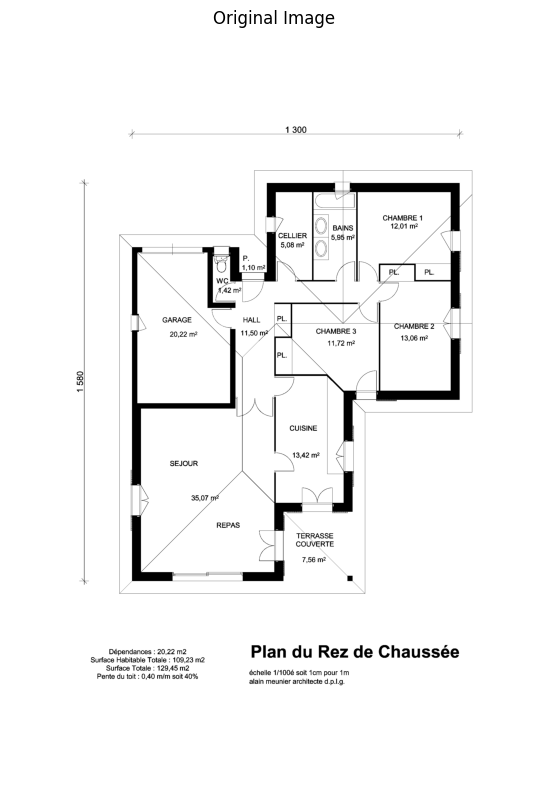

In [2]:
image_path = "../data/PNG/Ia_LS0701_sommaire.png"  # Change to your image path

image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Image shape : {image.shape}")
print(f"Image dtype : {image.dtype}")

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 3: Image Preprocessing

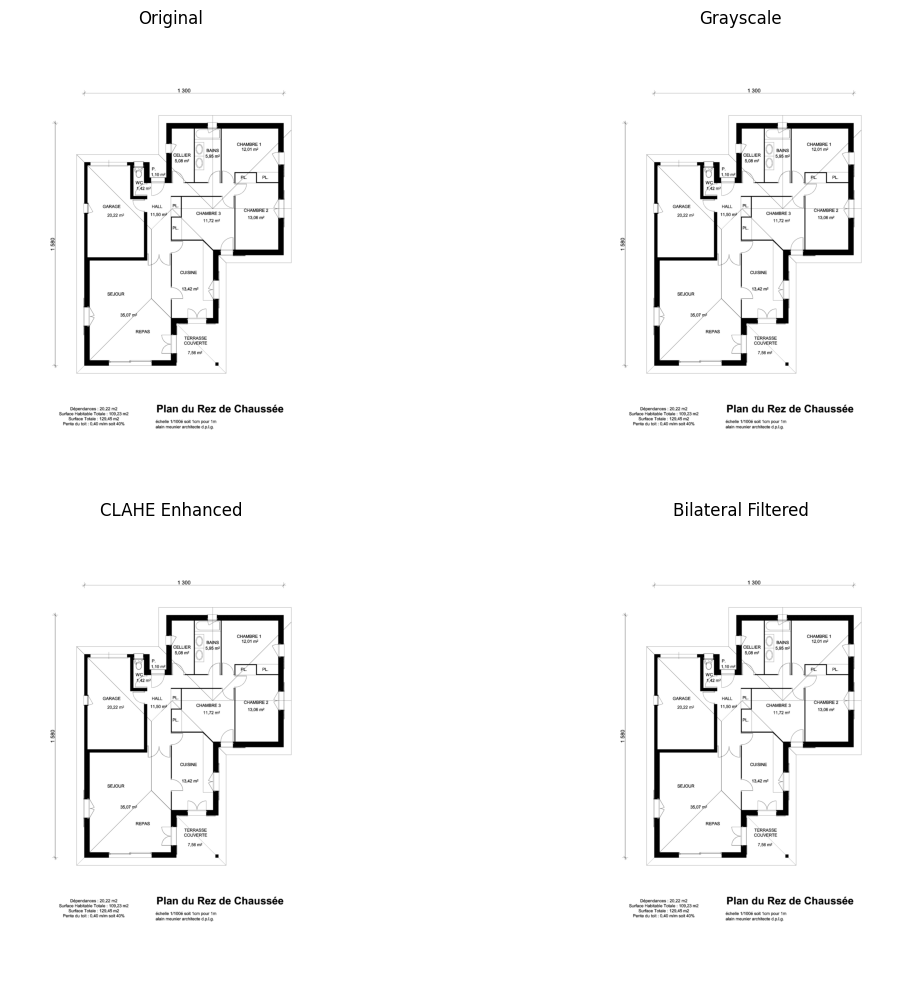

In [3]:
def preprocess_image(image):
    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Denoise
    denoised = cv2.fastNlMeansDenoising(gray, h=10)

    # CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    # Bilateral filter — preserves edges while smoothing
    bilateral = cv2.bilateralFilter(enhanced, 9, 75, 75)

    return bilateral, gray, enhanced


preprocessed, gray, enhanced = preprocess_image(image)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(image_rgb);          axes[0, 0].set_title("Original");           axes[0, 0].axis("off")
axes[0, 1].imshow(gray, cmap="gray");  axes[0, 1].set_title("Grayscale");          axes[0, 1].axis("off")
axes[1, 0].imshow(enhanced, cmap="gray"); axes[1, 0].set_title("CLAHE Enhanced");  axes[1, 0].axis("off")
axes[1, 1].imshow(preprocessed, cmap="gray"); axes[1, 1].set_title("Bilateral Filtered"); axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

## Step 4: Initialize EasyOCR Reader

In [4]:
# gpu=True uses CUDA if available, falls back to CPU otherwise
reader = easyocr.Reader(['en', 'fr', 'it'], gpu=False)
print("EasyOCR reader initialized")

Using CPU. Note: This module is much faster with a GPU.


EasyOCR reader initialized


## Step 5: Perform OCR

In [5]:
# EasyOCR returns: list of (bbox, text, confidence)
# bbox format: [[x1,y1],[x2,y1],[x2,y2],[x1,y2]]
raw_results = reader.readtext(image_path)

print(f"Total detections: {len(raw_results)}\n")

ocr_data = []
for idx, (bbox, text, confidence) in enumerate(raw_results):
    ocr_data.append({
        'index': idx,
        'text': text,
        'confidence': confidence,
        'box': np.array(bbox, dtype=np.int32)
    })
    print(f"[{idx:02d}] {text:30s}  conf={confidence:.4f}")

/Users/michaeleko/miniconda3/envs/floor-plan/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Total detections: 43

[00] 300                             conf=0.9407
[01] CHAMBRE                         conf=0.9999
[02] BAINS                           conf=0.9991
[03] 12,01 m2                        conf=0.7982
[04] CELLIER                         conf=0.9998
[05] 5,95 m?                         conf=0.7160
[06] 5,08 m2                         conf=0.9295
[07] P                               conf=0.9982
[08] 1,10 m2                         conf=0.9187
[09] PX                              conf=0.7196
[10] PL                              conf=0.9997
[11] WC                              conf=0.9915
[12] 1,42 m2                         conf=0.8727
[13] GARAGE                          conf=0.9999
[14] HALL                            conf=0.7363
[15] PL                              conf=0.9991
[16] CHAMBRE 2                       conf=0.9806
[17] 20,22 m2                        conf=0.8401
[18] 11,50 m?                        conf=0.8736
[19] CHAMBRE 3                       conf=0.999

## Step 6: Filter by Confidence Threshold (Optional)

In [6]:
CONFIDENCE_THRESHOLD = 0.1

filtered_data = [d for d in ocr_data if d['confidence'] >= CONFIDENCE_THRESHOLD]
print(f"Detections above threshold {CONFIDENCE_THRESHOLD}: {len(filtered_data)} / {len(ocr_data)}")

Detections above threshold 0.1: 43 / 43


## Step 7: Visualize OCR Results on Image

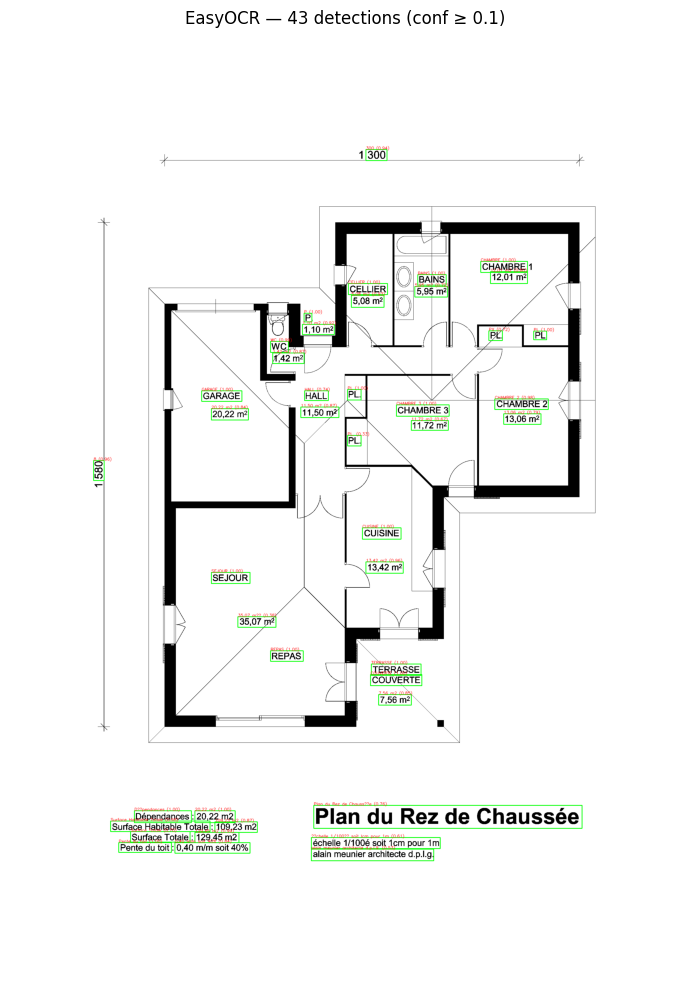

In [7]:
image_with_boxes = image.copy()

for data in filtered_data:
    box = data['box']
    text = data['text']
    confidence = data['confidence']

    # Draw polygon bounding box
    cv2.polylines(image_with_boxes, [box], isClosed=True, color=(0, 255, 0), thickness=2)

    # Label at top-left corner of the box
    top_left = tuple(box[0])
    label = f"{text} ({confidence:.2f})"
    cv2.putText(image_with_boxes, label, top_left,
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)

vis_rgb = cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 10))
plt.imshow(vis_rgb)
plt.title(f"EasyOCR — {len(filtered_data)} detections (conf ≥ {CONFIDENCE_THRESHOLD})")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 8: Crop Each Detected Text Region

In [8]:
def crop_text_region(image, box, padding=8):
    """Crop bounding-box region with optional padding."""
    x_coords = box[:, 0]
    y_coords = box[:, 1]
    x_min = max(0, int(np.min(x_coords)) - padding)
    y_min = max(0, int(np.min(y_coords)) - padding)
    x_max = min(image.shape[1], int(np.max(x_coords)) + padding)
    y_max = min(image.shape[0], int(np.max(y_coords)) + padding)
    return image[y_min:y_max, x_min:x_max], (x_min, y_min, x_max, y_max)


cropped_texts = []
for data in filtered_data:
    crop, coords = crop_text_region(image, data['box'], padding=8)
    if crop.size > 0:
        cropped_texts.append({
            'index': data['index'],
            'text': data['text'],
            'confidence': data['confidence'],
            'image': crop,
            'coordinates': coords
        })

print(f"Cropped {len(cropped_texts)} text regions")

Cropped 43 text regions


## Step 9: Display Cropped Regions

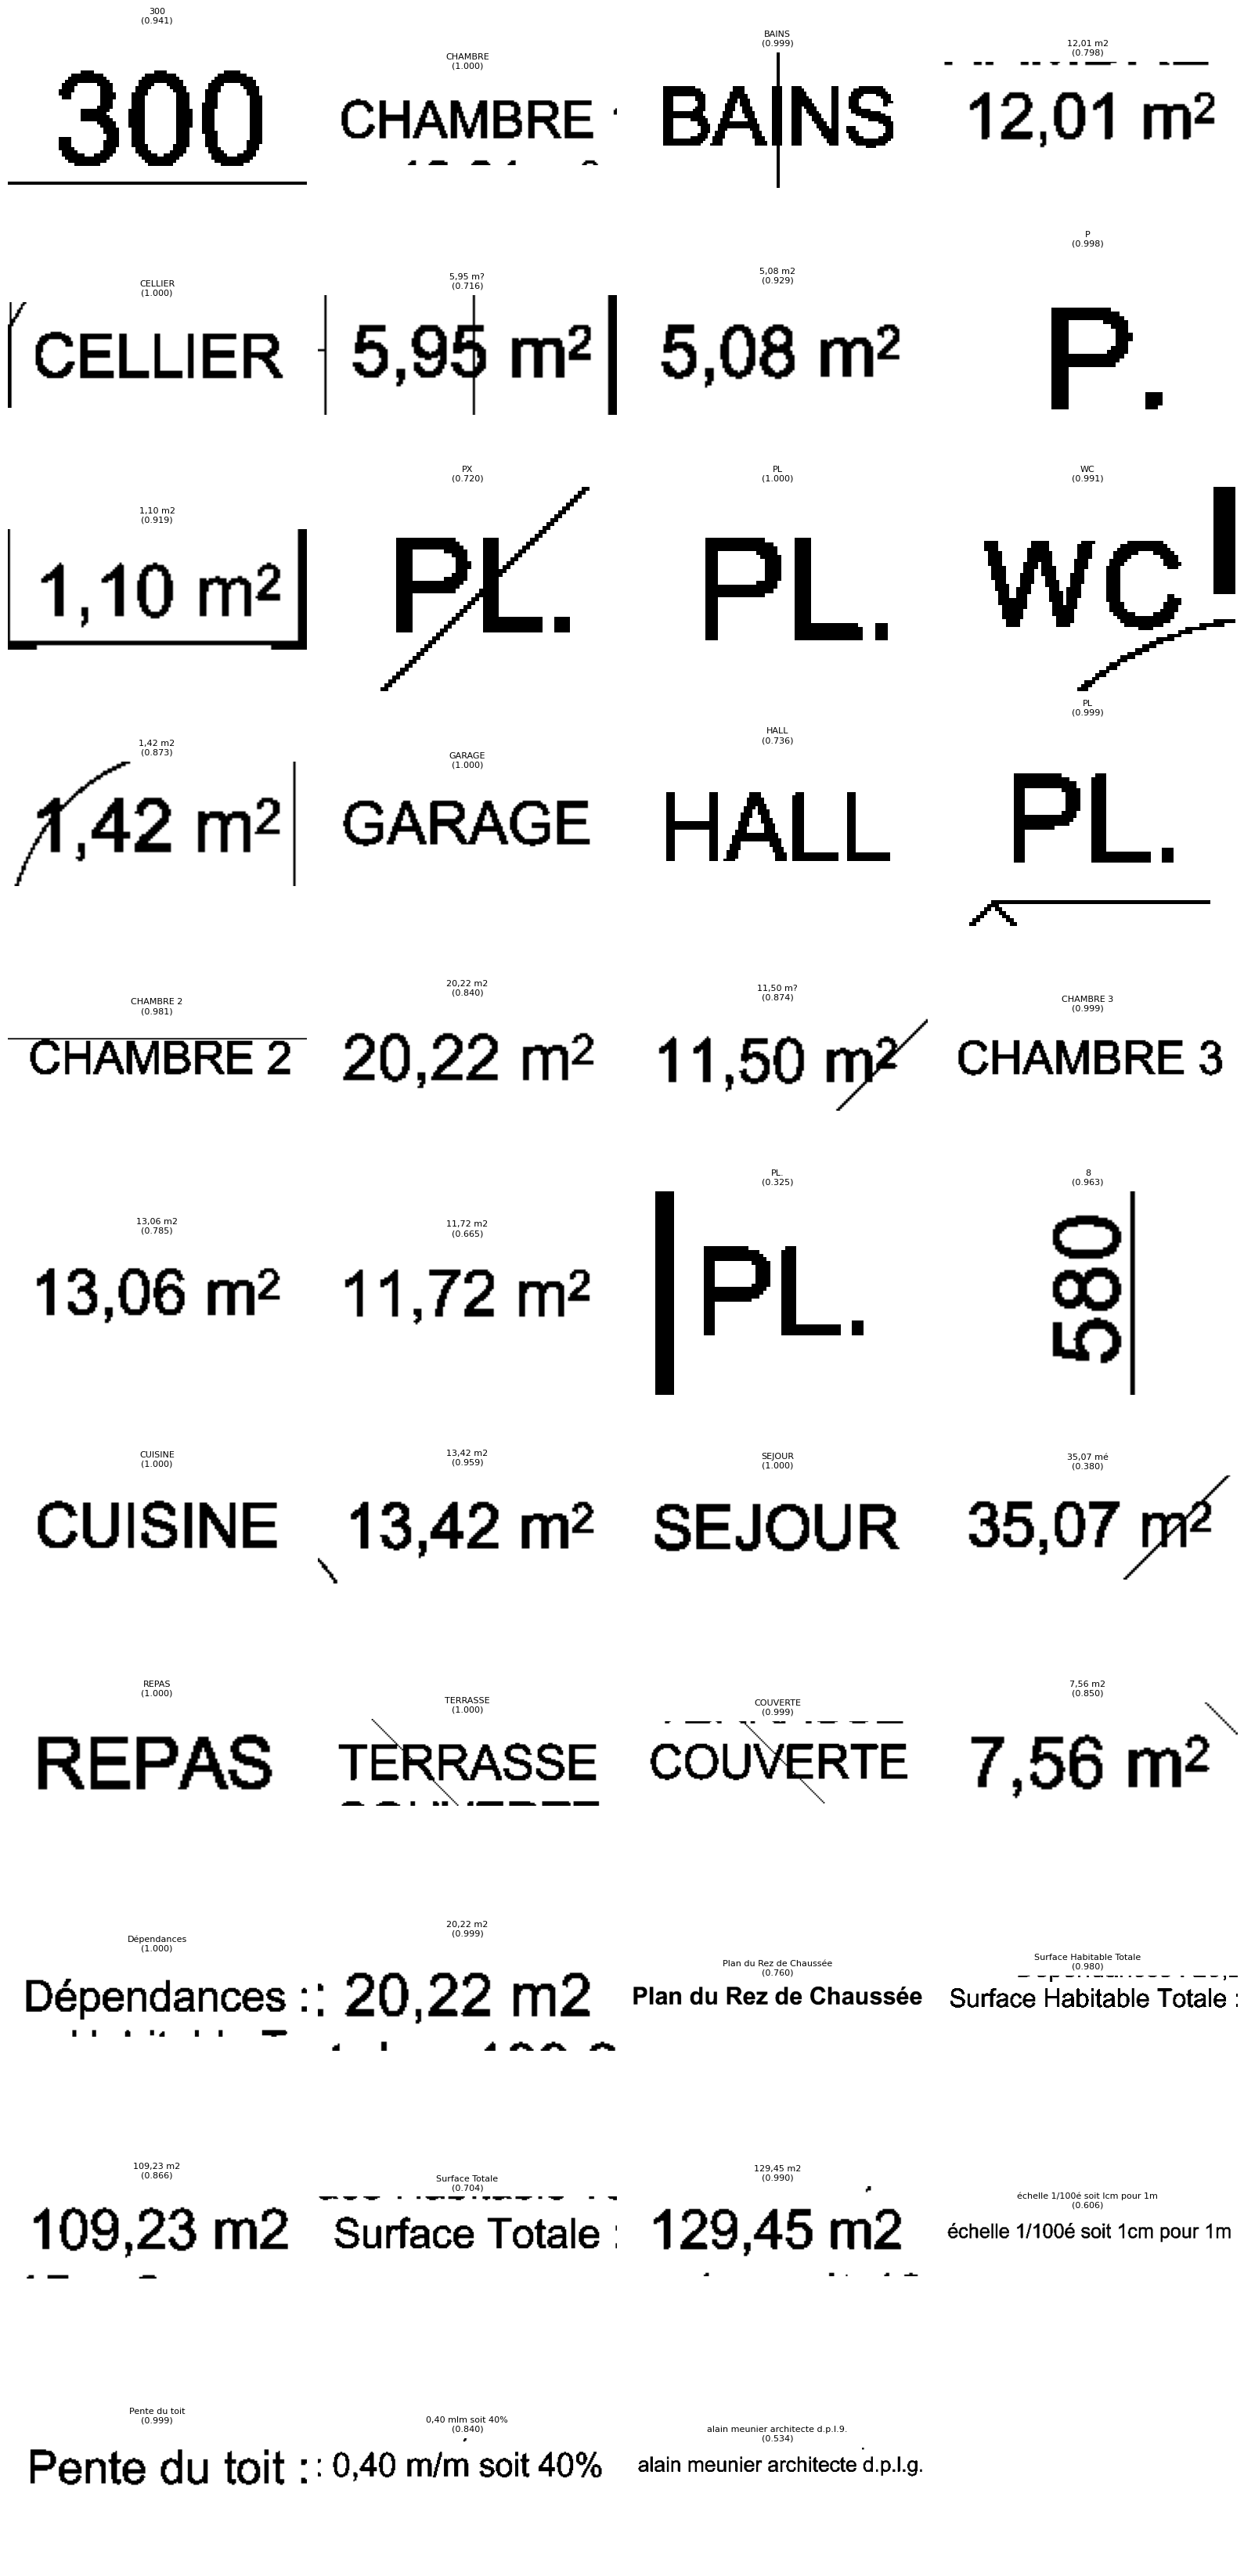

In [9]:
cols = 4
rows = max(1, (len(cropped_texts) + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = np.array(axes).flatten()

for idx, crop_data in enumerate(cropped_texts):
    crop_rgb = cv2.cvtColor(crop_data['image'], cv2.COLOR_BGR2RGB)
    axes[idx].imshow(crop_rgb)
    axes[idx].set_title(f"{crop_data['text']}\n({crop_data['confidence']:.3f})", fontsize=8)
    axes[idx].axis("off")

for idx in range(len(cropped_texts), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## Step 10: Save Cropped Regions to Disk

In [10]:
output_dir = "cropped_texts_easyocr"
# os.makedirs(output_dir, exist_ok=True)

# for crop_data in cropped_texts:
#     safe_text = crop_data['text'].replace(' ', '_').replace('/', '_')[:40]
#     filename = f"{output_dir}/{crop_data['index']:02d}_{safe_text}.png"
#     cv2.imwrite(filename, crop_data['image'])
#     print(f"Saved: {filename}")

# print(f"\nSaved {len(cropped_texts)} crops to '{output_dir}/'")

## Step 11: Complete Pipeline Function

## Step 12: Remove Text from Image (Inpainting)

In [11]:
def build_text_mask(image, ocr_data, dilation_px=5):
    """Build a binary mask where detected text regions are white (255)."""
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    for data in ocr_data:
        box = data['box'].astype(np.int32)
        cv2.fillPoly(mask, [box], 255)

    if dilation_px > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT, (dilation_px * 2 + 1, dilation_px * 2 + 1)
        )
        mask = cv2.dilate(mask, kernel)

    return mask


def remove_text(image, mask):
    """Replace masked text regions with pure white."""
    result = image.copy()
    result[mask == 255] = 255
    return result


# Build mask from filtered detections
text_mask = build_text_mask(image, filtered_data, dilation_px=5)

# Replace text regions with white
image_no_text = remove_text(image, text_mask)

print("Text removal complete")

Text removal complete


## Step 13: Visualize Mask and Result

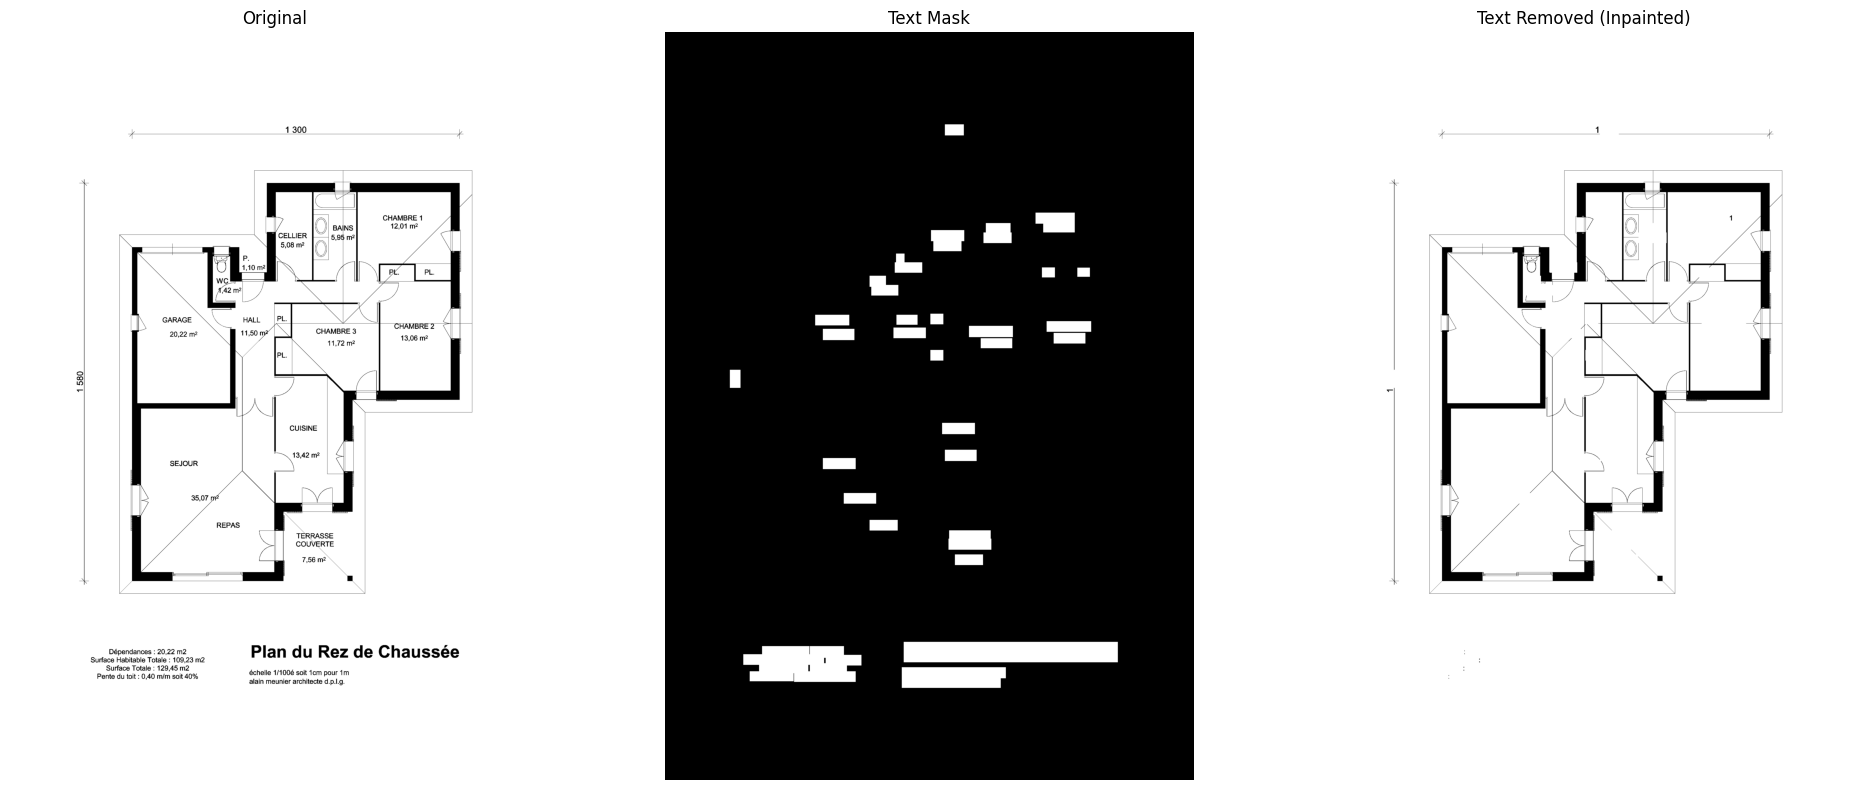

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(text_mask, cmap="gray")
axes[1].set_title("Text Mask")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(image_no_text, cv2.COLOR_BGR2RGB))
axes[2].set_title("Text Removed (Inpainted)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Step 14: Save Result

In [13]:
output_path = "Ia_LS0701_sommaire_no_text.png"
cv2.imwrite(output_path, image_no_text)
print(f"Saved: {output_path}")

Saved: Ia_LS0701_sommaire_no_text.png


## Step 15: Batch — Remove Text from All PNGs (Multi-Angle)

In [ ]:
from pathlib import Path
from tqdm import tqdm

INPUT_DIR  = Path("../data/PNG")
OUTPUT_DIR = Path("../data/PNG/no_text")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIDENCE_THRESHOLD = 0.1
DILATION_PX = 5
ANGLE_STEP = 90        # degrees, 0→330 clockwise


def rotate_image(image, angle):
    """Rotate image clockwise by angle degrees, expanding canvas to fit."""
    h, w = image.shape[:2]
    cx, cy = w / 2, h / 2
    M = cv2.getRotationMatrix2D((cx, cy), -angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)
    M[0, 2] += (new_w / 2) - cx
    M[1, 2] += (new_h / 2) - cy
    return cv2.warpAffine(image, M, (new_w, new_h),
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=(255, 255, 255))


def rotate_mask_back(mask_rotated, original_shape, angle):
    """Rotate a mask from rotated-space back to original-space."""
    h_rot, w_rot = mask_rotated.shape[:2]
    h_orig, w_orig = original_shape[:2]
    cx_rot, cy_rot = w_rot / 2, h_rot / 2
    M = cv2.getRotationMatrix2D((cx_rot, cy_rot), angle, 1.0)
    M[0, 2] += (w_orig / 2) - cx_rot
    M[1, 2] += (h_orig / 2) - cy_rot
    return cv2.warpAffine(mask_rotated, M, (w_orig, h_orig),
                          flags=cv2.INTER_NEAREST,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=0)


def ocr_detections(img_array, confidence_threshold):
    """Run EasyOCR on a numpy array and return filtered detection list."""
    raw = reader.readtext(img_array)
    return [
        {'box': np.array(bbox, dtype=np.int32), 'text': text, 'confidence': conf}
        for bbox, text, conf in raw
        if conf >= confidence_threshold
    ]


def remove_text_multiangle(image, confidence_threshold=0.1, dilation_px=5, angle_step=30):
    """
    For each angle 0, 30, 60, … 330 (clockwise):
      1. Rotate the image.
      2. Run OCR on the rotated image.
      3. Build a text mask in rotated space.
      4. Rotate the mask back to the original orientation.
      5. Accumulate into a combined mask.
    Then fill all masked pixels with pure white.
    """
    h, w = image.shape[:2]
    combined_mask = np.zeros((h, w), dtype=np.uint8)

    for angle in range(0, 360, angle_step):
        rotated    = rotate_image(image, angle)
        detections = ocr_detections(rotated, confidence_threshold)
        if not detections:
            continue
        rot_mask  = build_text_mask(rotated, detections, dilation_px=dilation_px)
        orig_mask = rotate_mask_back(rot_mask, image.shape, angle)
        combined_mask = cv2.bitwise_or(combined_mask, orig_mask)

    result = remove_text(image, combined_mask)
    return result, combined_mask


# ── Batch loop ────────────────────────────────────────────────────────────────
png_files = sorted(p for p in INPUT_DIR.glob("*.png") if p.parent == INPUT_DIR)
print(f"Found {len(png_files)} PNG files | angles: 0°→330° step {ANGLE_STEP}°\n")

failed = []

for img_path in tqdm(png_files, desc="Removing text"):
    out_path = OUTPUT_DIR / img_path.name
    if out_path.exists():
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        print(f"  [SKIP] Cannot read {img_path.name}")
        failed.append(img_path.name)
        continue

    try:
        result, _ = remove_text_multiangle(
            img,
            confidence_threshold=CONFIDENCE_THRESHOLD,
            dilation_px=DILATION_PX,
            angle_step=ANGLE_STEP,
        )
        cv2.imwrite(str(out_path), result)
    except Exception as e:
        print(f"  [ERROR] {img_path.name}: {e}")
        failed.append(img_path.name)

print(f"\nDone. Saved to {OUTPUT_DIR}")
if failed:
    print(f"Failed ({len(failed)}): {failed}")

Found 90 PNG files | angles: 0°→330° step 90°



Removing text: 100%|██████████| 90/90 [53:55<00:00, 35.95s/it] 


Done. Saved to ../data/PNG/no_text_new
